In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [121]:
df = pd.read_csv("housing.csv")

In [122]:
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


In [123]:
numerics = df.select_dtypes("number").drop(["Postcode", "Price"], axis=1).columns.to_list()

In [124]:
numerics

['Rooms',
 'Distance',
 'Bedroom2',
 'Bathroom',
 'Car',
 'Landsize',
 'BuildingArea',
 'YearBuilt',
 'Lattitude',
 'Longtitude',
 'Propertycount']

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


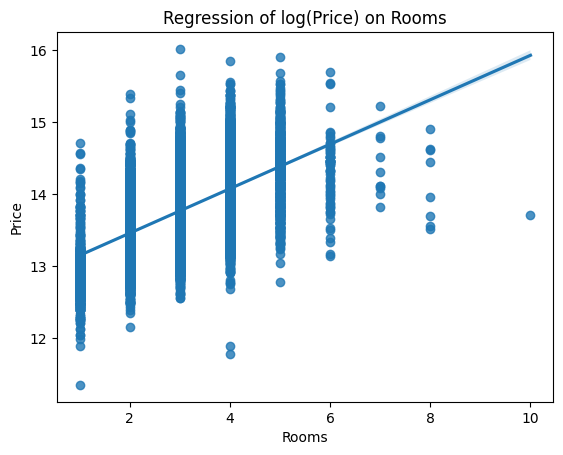

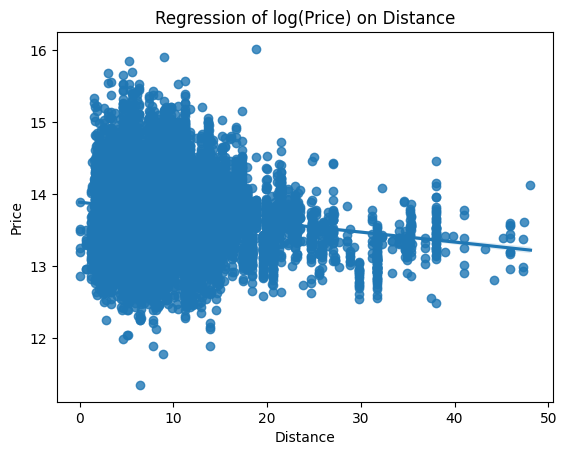

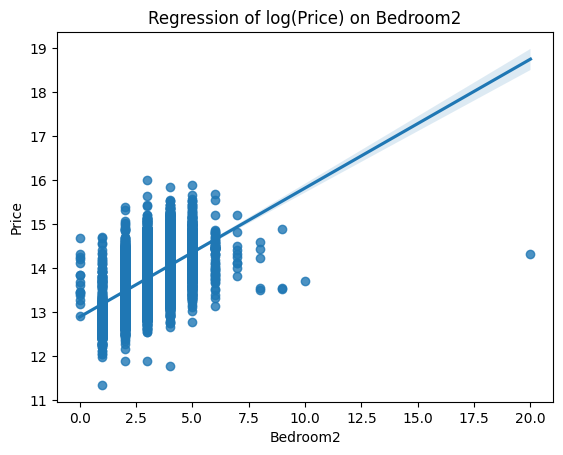

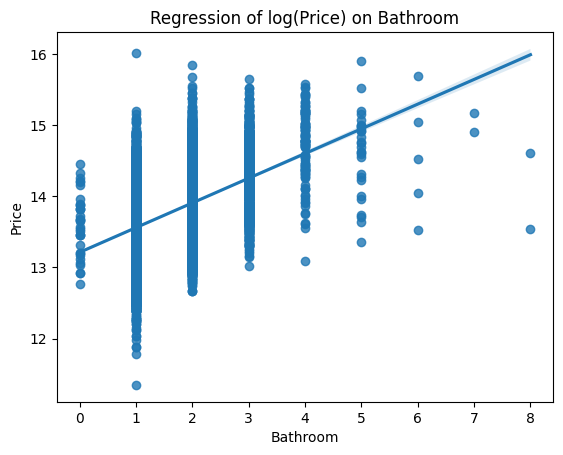

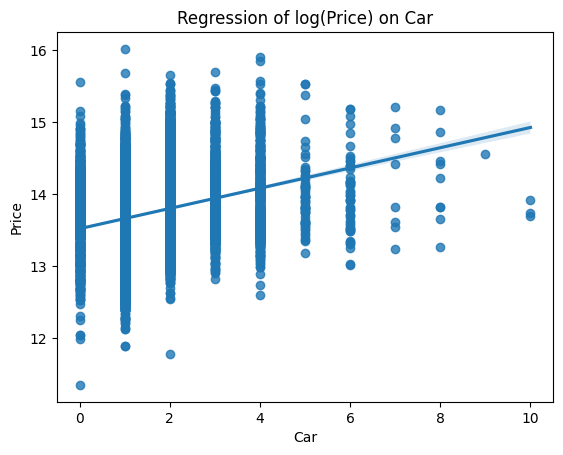

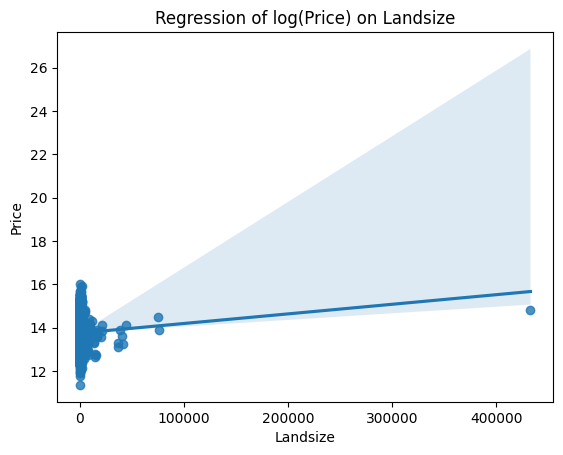

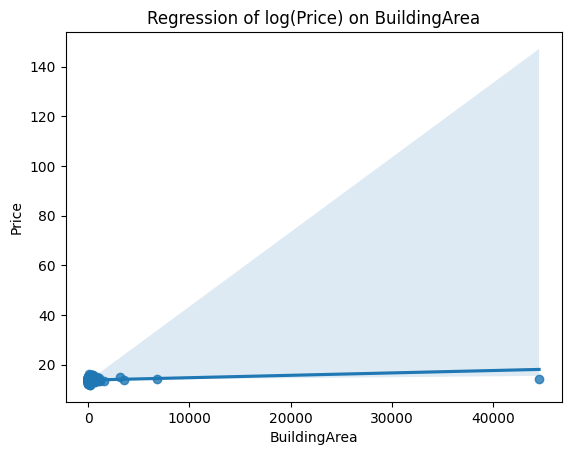

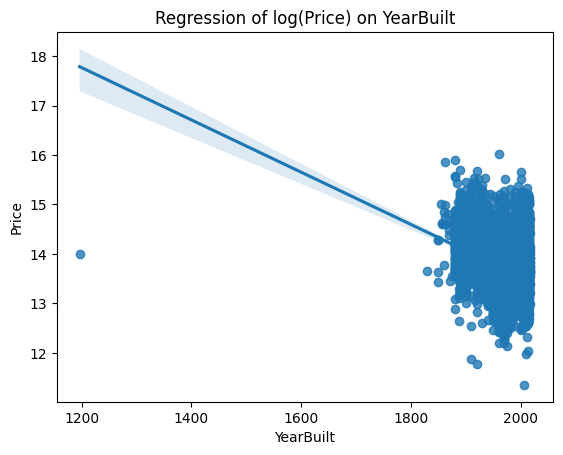

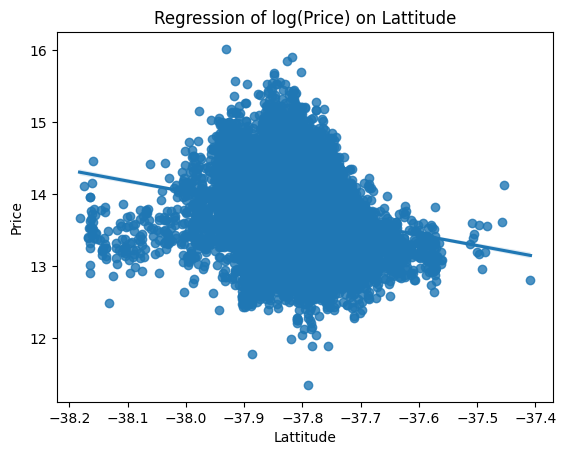

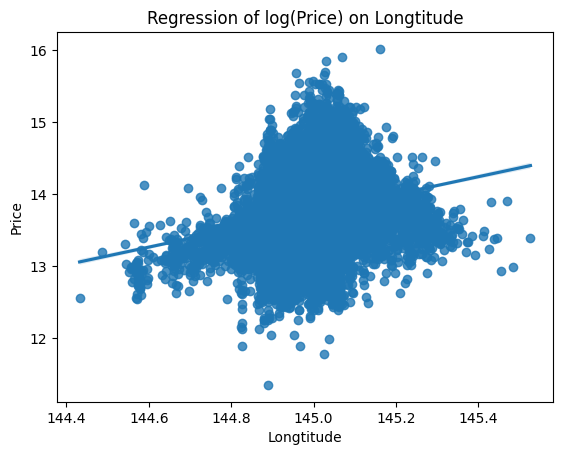

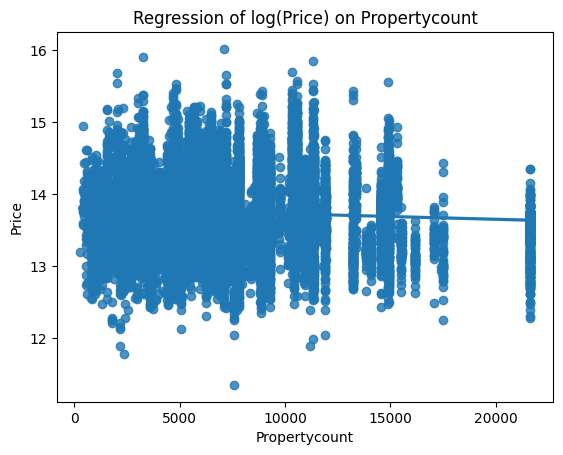

In [125]:
for feature in numerics:
    sns.regplot(x=df[feature], y=np.log(df["Price"]))
    plt.title(f"Regression of log(Price) on {feature}")
    plt.show()

In [126]:
numerics.remove("Propertycount")
numerics.remove("Distance")


In [127]:
df_filtered = df.query("YearBuilt > 1600 and Landsize < 100000").copy()

In [128]:
numerics

['Rooms',
 'Bedroom2',
 'Bathroom',
 'Car',
 'Landsize',
 'BuildingArea',
 'YearBuilt',
 'Lattitude',
 'Longtitude']

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


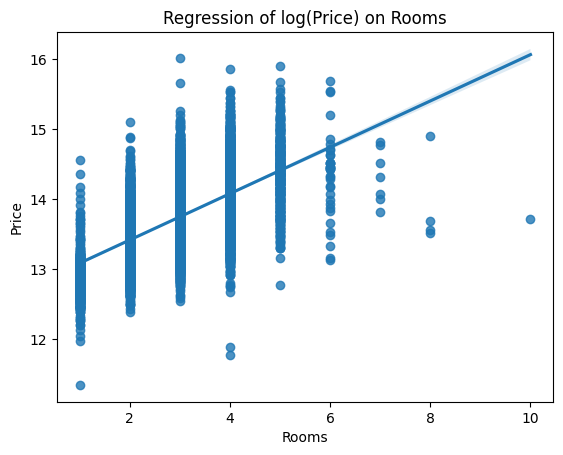

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


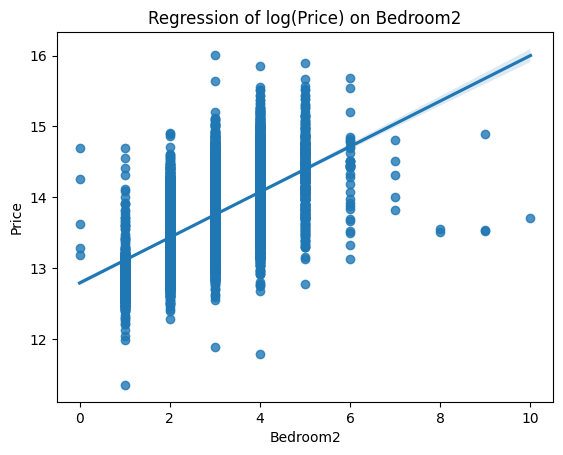

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


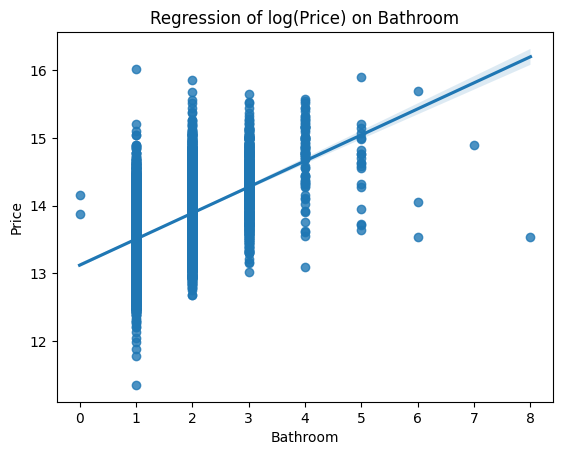

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


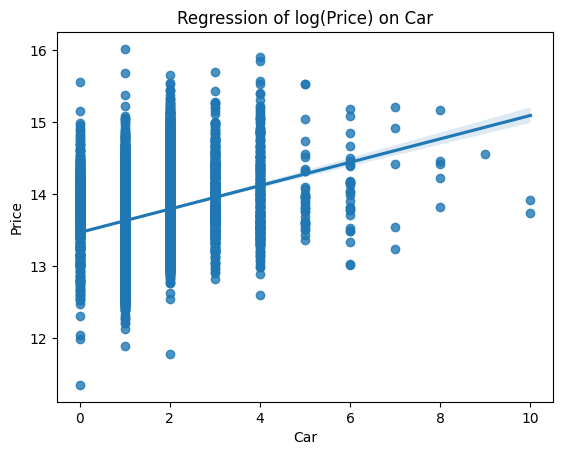

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


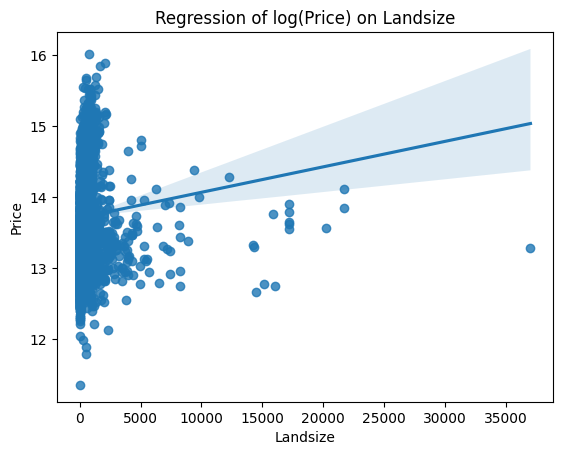

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


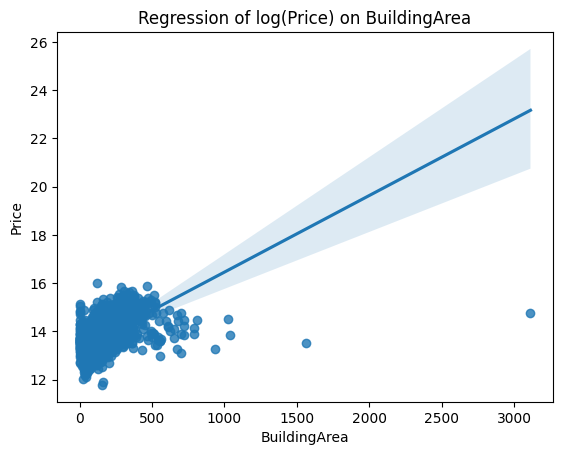

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


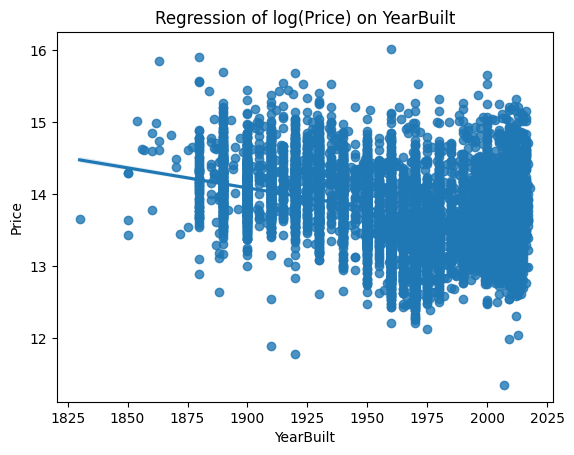

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


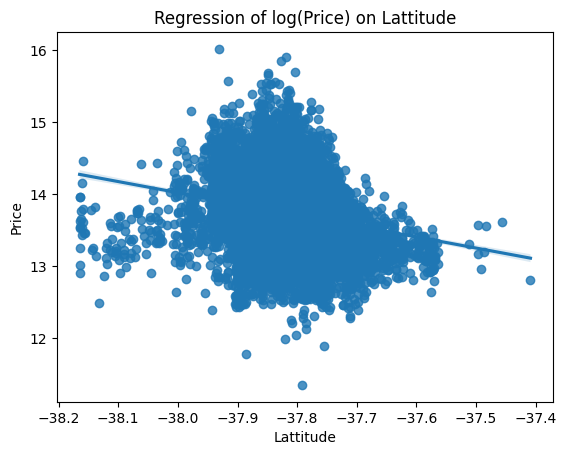

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


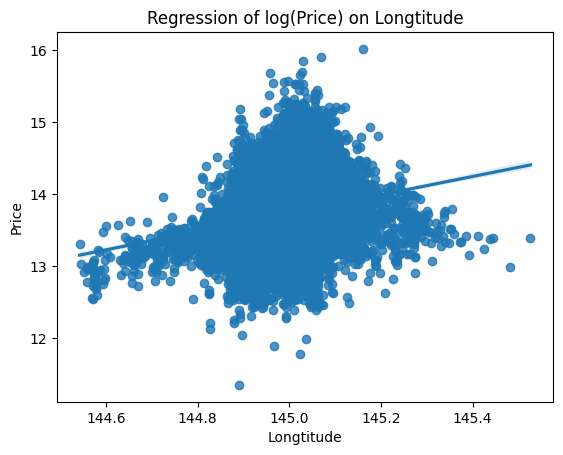

In [129]:
for feature in numerics:
    sns.regplot(x=df_filtered.drop("Price", axis=1)[feature], y=np.log(df_filtered["Price"]))
    plt.title(f"Regression of log(Price) on {feature}")
    plt.show()

# Assess categorics against target

In [130]:
categorics = ["Type", "Method", "Regionname"]
categorics_predictors = ["Type"]

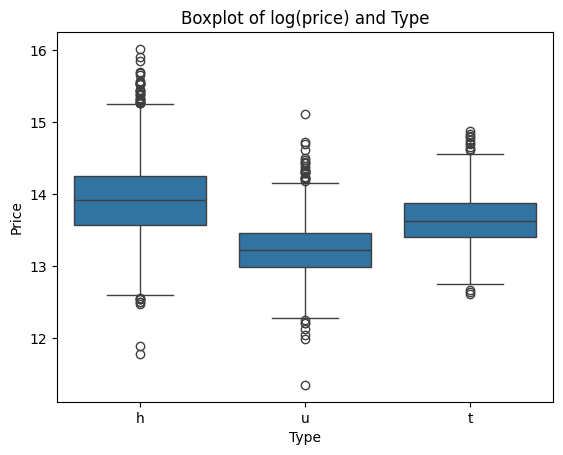

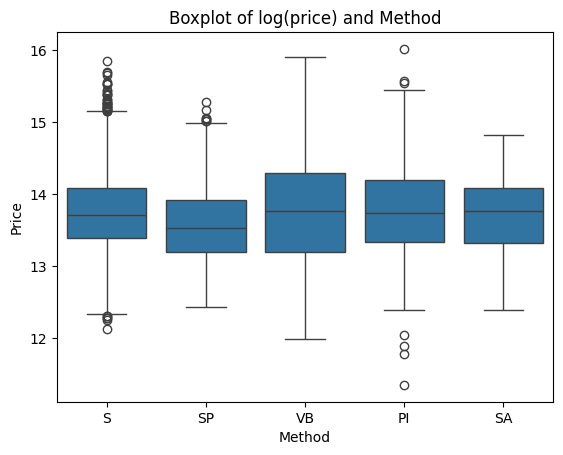

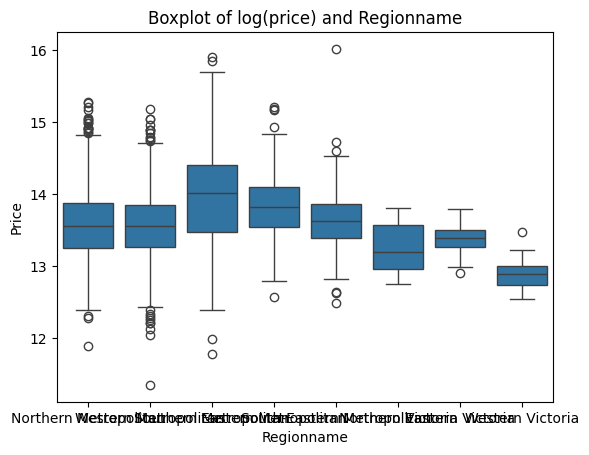

In [131]:
for feature in categorics:
    sns.boxplot(x=df_filtered.drop("Price", axis=1)[feature], y=np.log(df["Price"]))
    plt.title(f"Boxplot of log(price) and {feature}")
    plt.show()

# Format design matrix and get dummies

In [132]:
# Get dummies
X = df_filtered[numerics + categorics_predictors].copy()
X["Car"] = X["Car"].fillna(X["Car"].median())
X["BuildingArea"] = X["BuildingArea"].fillna(X["BuildingArea"].mean())
dummies = pd.get_dummies(X["Type"], prefix="Type_", drop_first=True, dtype=int)
X = pd.concat([X.drop("Type", axis=1), dummies], axis=1)
y = np.log(df_filtered["Price"])

In [133]:
# train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [134]:
# Standardize numeric predictors for regularization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[numerics] = scaler.fit_transform(X_train[numerics])
X_test[numerics] = scaler.transform(X_test[numerics])

<Axes: xlabel='Price', ylabel='Density'>

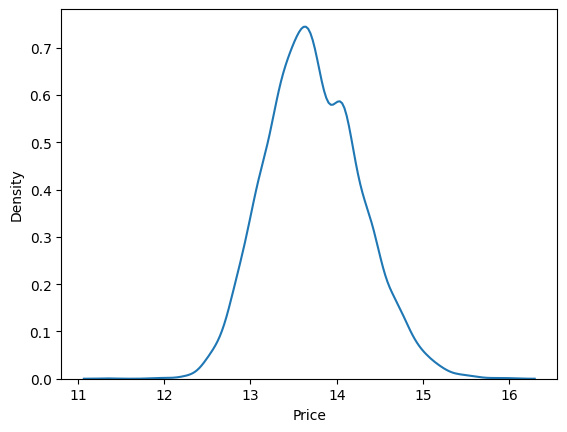

In [135]:
sns.kdeplot(y_train)

In [136]:
# Gamma
y_train = np.exp(y_train)/100000
y_test = np.exp(y_test)/100000

In [137]:
y_train

7493      8.00
6386      3.66
5548      3.80
6677      9.50
1912      8.50
         ...  
8675      3.80
11637     5.10
5482      9.08
12910    15.95
1045     37.00
Name: Price, Length: 6563, dtype: float64

In [140]:
X_train

,Rooms,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Type__t,Type__u
7493,-0.950837,-0.927519,0.599236,-0.630600,-0.319444,0.002738,0.804599,0.306884,0.996392,0,1
6386,-1.970001,-1.946998,-0.812895,-0.630600,-0.531242,-1.468783,0.061456,-0.468710,0.132743,0,1
5548,-1.970001,-1.946998,-0.812895,-0.630600,-0.531242,0.002738,-0.131211,-0.314602,-0.251858,0,1
6677,0.068327,0.091960,-0.812895,0.431404,-0.271898,-0.803175,-2.333117,-0.137756,-1.014245,0,0
1912,-0.950837,-0.927519,-0.812895,-0.630600,-0.130339,-0.680921,-0.956926,0.938475,-0.339489,0,0
...,...,...,...,...,...,...,...,...,...,...,...
8675,-1.970001,-1.946998,-0.812895,-0.630600,-0.435068,-1.441615,0.419265,-0.250180,-1.060982,0,1
11637,0.068327,0.091960,0.599236,0.431404,-0.153032,0.242779,1.355075,3.037505,-0.826618,0,0
5482,0.068327,0.091960,-0.812895,0.431404,0.216534,-0.246238,-0.406449,0.944791,0.793868,0,0
12910,1.087492,1.111439,-0.812895,0.431404,0.096587,0.324282,-0.131211,-1.308852,0.644506,0,0


In [139]:
# Gamma GLM
Gamma = sm.GLM(y_train, X_train, sm.families.Gamma(sm.families.links.Log())).fit()
print(Gamma.summary())

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:527: RuntimeWarning: overflow encountered in exp
  return np.exp(z)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:774: RuntimeWarning: divide by zero encountered in divide
  endog_mu = self._clean(endog / mu)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:775: RuntimeWarning: divide by zero encountered in divide
  resid_dev = -np.log(endog_mu) + (endog - mu) / mu
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:775: RuntimeWarning: invalid value encountered in divide
  resid_dev = -np.log(endog_mu) + (endog - mu) / mu
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:775: RuntimeWarning: invalid value encountered in add
  resid_dev = -np.log(endog_mu) + (endog - mu) / mu
/opt/minicond

ValueError: NaN, inf or invalid value detected in weights, estimation infeasible.

In [ ]:
# Lognormal GLM
LogN = sm.GLM(y_train, X_train, family=sm.families.Gaussian(link=sm.families.links.Identity())).fit()
print(LogN.summary())
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE, r2_score as R2
preds = LogN.predict(X_test)
print(f"MSE: {MSE(y_test, preds)}, MAE: {MAE(y_test, preds)}, R2: {R2(y_test, preds)}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Price   No. Observations:                 6563
Model:                            GLM   Df Residuals:                     6552
Model Family:                Gaussian   Df Model:                           10
Link Function:               Identity   Scale:                          96.280
Method:                          IRLS   Log-Likelihood:                -24294.
Date:                Tue, 29 Jul 2025   Deviance:                   6.3082e+05
Time:                        09:59:40   Pearson chi2:                 6.31e+05
No. Iterations:                     3   Pseudo R-squ. (CS):             -1.705
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Rooms            3.2900      0.426      7.718   

<Axes: xlabel='None', ylabel='Price'>

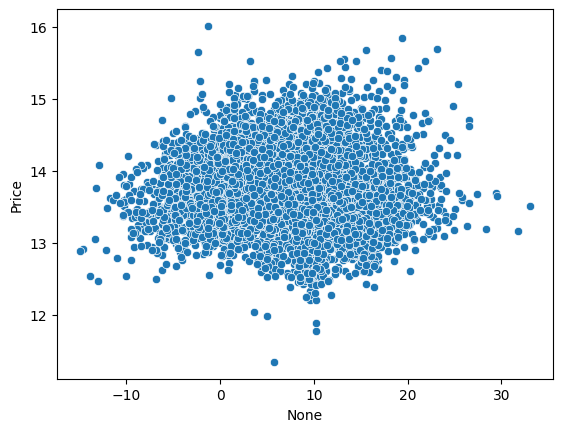

In [ ]:
sns.scatterplot(x=LogN.fittedvalues, y=y_train)

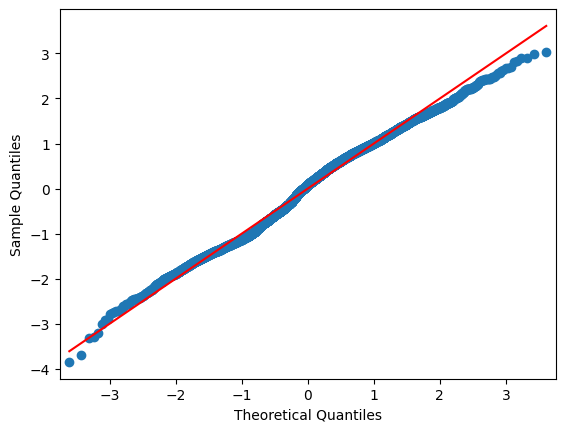

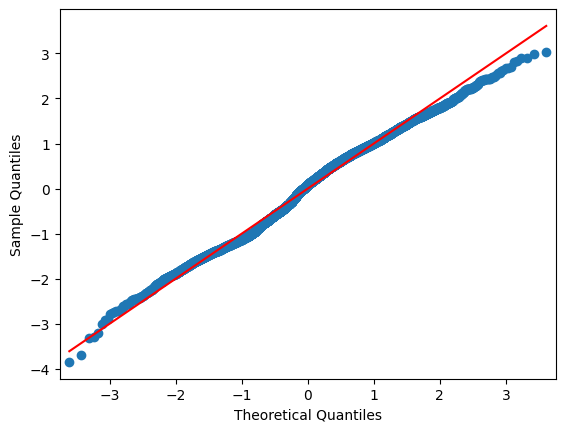

In [ ]:
sm.graphics.qqplot(stats.zscore(LogN.resid_deviance), line="s")

<Axes: xlabel='None'>

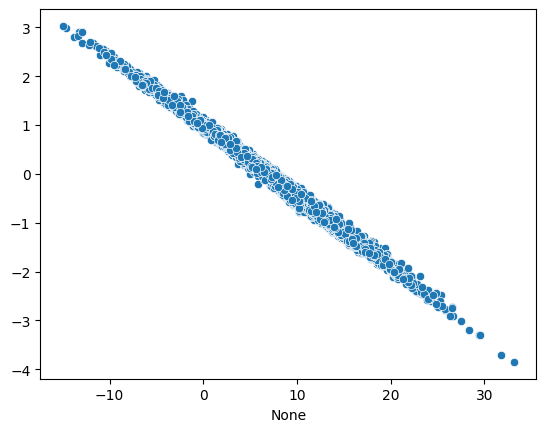

In [ ]:
sns.scatterplot(x=LogN.fittedvalues, y=stats.zscore(LogN.resid_deviance))

In [ ]:
LogN.fittedvalues

3671      6.765454
8604     14.517269
6296     16.865130
11537    -0.211430
5306      8.426392
           ...    
6080     -0.667861
6076      5.626754
594       7.812158
2332     17.693865
1996      1.916782
Length: 6563, dtype: float64

In [143]:
# LightGBM
from lightgbm import LGBMRegressor
model = LGBMRegressor(n_estimators=1000).fit(X_train, y_train)
preds= model.predict(X_test)

print(f"MSE: {MSE(y_test, preds)}, MAE: {MAE(y_test, preds)}, R2: {R2(y_test, preds)}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000337 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1177
[LightGBM] [Info] Number of data points in the train set: 6563, number of used features: 11
[LightGBM] [Info] Start training from score 10.663043
MSE: 7.873523160619468, MAE: 1.67135396719325, R2: 0.8103343532437501


In [144]:
y_train

7493      8.00
6386      3.66
5548      3.80
6677      9.50
1912      8.50
         ...  
8675      3.80
11637     5.10
5482      9.08
12910    15.95
1045     37.00
Name: Price, Length: 6563, dtype: float64